In [1]:
import yfinance as yf

#data = yf.download('JPM, SKY, AAPL', start = '2016-04-01', end = '2026-04-01')
#data.to_csv("sp_data.csv")

In [2]:
import pandas as pd

stock = pd.read_csv("sp_data.csv", header=[0,1], index_col = 0, parse_dates = True)
stock.index = pd.to_datetime(stock.index)
stock

Price            Close                               High              \
Ticker            AAPL         JPM        SKY        AAPL         JPM   
Date                                                                    
2016-04-01   24.910582   45.548195   8.538766   24.912847   45.692746   
2016-04-04   25.166512   45.371918   8.442826   25.408846   45.655491   
2016-04-05   24.869823   44.728130   8.711461   25.078187   45.088348   
2016-04-06   25.130266   45.073013   8.605926   25.134797   45.126662   
2016-04-07   24.582191   43.931053   8.471608   25.007974   44.781777   
...                ...         ...        ...         ...         ...   
2026-03-25  252.619995  293.915833  75.620003  255.000000  296.124530   
2026-03-26  252.889999  290.174957  74.419998  257.000000  293.487989   
2026-03-27  248.800003  281.399872  72.540001  255.490005  288.632845   
2026-03-30  246.630005  282.325134  72.250000  250.869995  285.787426   
2026-03-31  253.789993  292.662231  74.370003  255.479996  293.567602   

Price                         Low                               Open  \
Ticker            SKY        AAPL         JPM        SKY        AAPL   
Date                                                                   
2016-04-01   9.085631   24.505181   44.551568   8.155001   24.636540   
2016-04-04   8.903344   24.974002   45.187976   8.346885   25.007974   
2016-04-05   8.874561   24.781496   44.613167   8.039873   24.801880   
2016-04-06   8.845779   24.731660   44.413894   8.538766   24.964936   
2016-04-07   8.759432   24.487070   43.739449   8.394855   24.901528   
...               ...         ...         ...        ...         ...   
2026-03-25  77.169998  251.600006  290.950995  72.980003  254.100006   
2026-03-26  76.720001  250.770004  289.249700  73.779999  252.119995   
2026-03-27  75.190002  248.070007  280.315425  72.449997  253.899994   
2026-03-30  73.699997  245.509995  280.892464  71.910004  250.070007   
2026-03-31  76.480003  247.100006  283.499134  72.720001  247.910004   

Price                                 Volume                    
Ticker             JPM        SKY       AAPL       JPM     SKY  
Date                                                            
2016-04-01   44.901529   8.932126  103496000  15417500  111400  
2016-04-04   45.555856   8.634708  149424800  12305000   92000  
2016-04-05   44.904406   8.394855  106314800  12886600  111600  
2016-04-06   44.590169   8.730649  105616400  12167900   84700  
2016-04-07   44.651485   8.663490  127207600  19226800   32300  
...                ...        ...        ...       ...     ...  
2026-03-25  292.652280  75.940002   28476700  12188200  475500  
2026-03-26  291.090256  75.010002   41796700   8669200  415600  
2026-03-27  287.667813  73.589996   47900000   9873300  585800  
2026-03-30  283.290197  73.250000   39446200  11734400  632600  
2026-03-31  287.001201  73.629997   49598100  12956900  657000  

[2514 rows x 15 columns]

In [3]:
close = stock['Close']
close

Ticker,AAPL,JPM,SKY
Date,,,
2016-04-01,24.910582,45.548195,8.538766
2016-04-04,25.166512,45.371918,8.442826
2016-04-05,24.869823,44.728130,8.711461
2016-04-06,25.130266,45.073013,8.605926
2016-04-07,24.582191,43.931053,8.471608
...,...,...,...
2026-03-25,252.619995,293.915833,75.620003
2026-03-26,252.889999,290.174957,74.419998
2026-03-27,248.800003,281.399872,72.540001


In [4]:
import numpy as np

log_returns = np.log(close/close.shift(1))
log_returns = log_returns.dropna()
log_returns

Ticker,AAPL,JPM,SKY
Date,,,
2016-04-04,0.010222,-0.003878,-0.011299
2016-04-05,-0.011859,-0.014291,0.031322
2016-04-06,0.010418,0.007681,-0.012189
2016-04-07,-0.022051,-0.025662,-0.015731
2016-04-08,0.001105,0.007301,-0.020596
...,...,...,...
2026-03-25,0.003887,0.010275,0.011839
2026-03-26,0.001068,-0.012809,-0.015996
2026-03-27,-0.016305,-0.030707,-0.025587


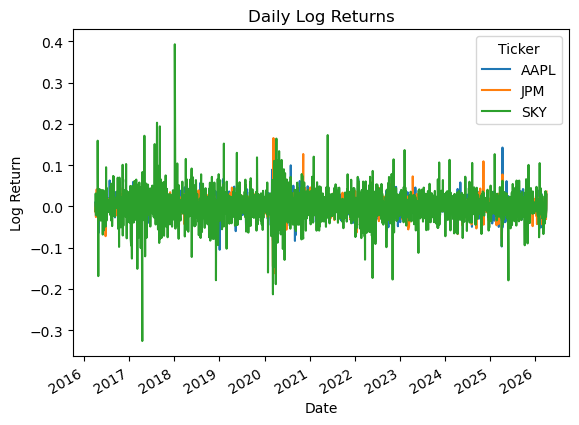

In [5]:
import matplotlib.pyplot as plt

log_returns.plot()
plt.title("Daily Log Returns")
plt.xlabel("Date")
plt.ylabel("Log Return")
plt.show()

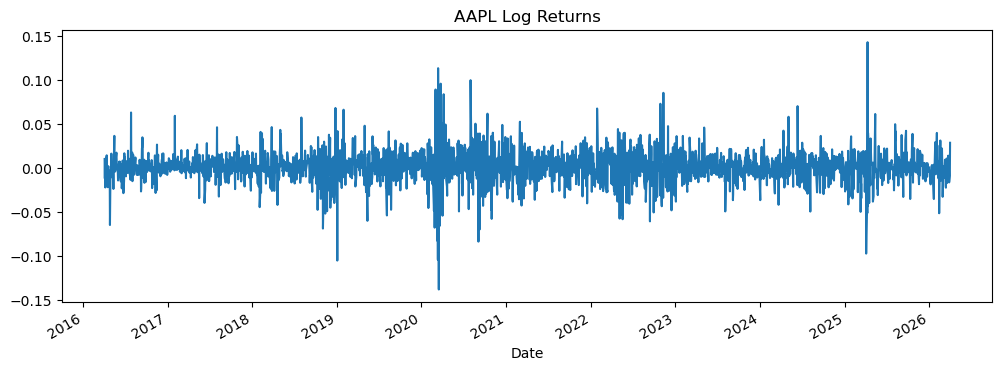

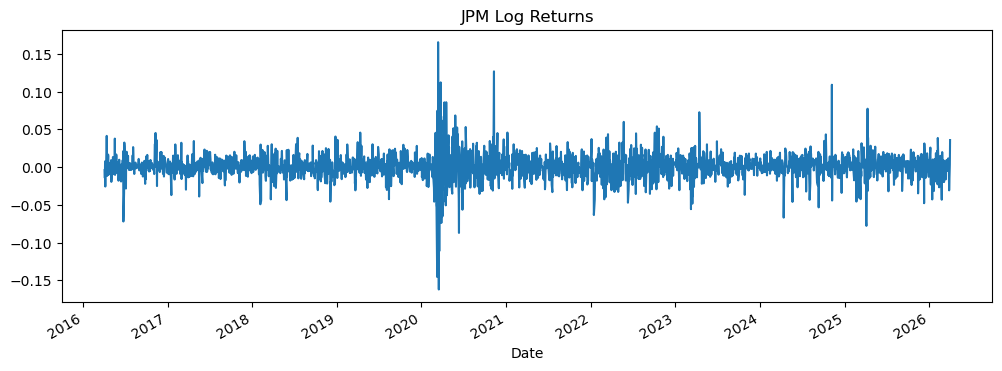

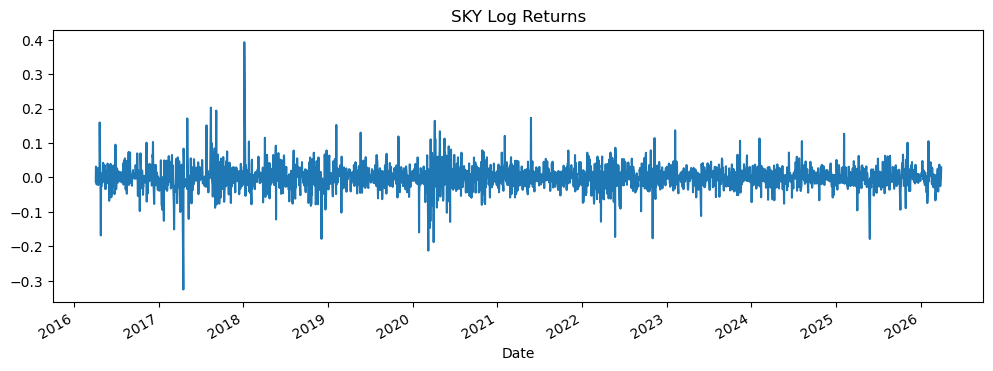

In [6]:
log_returns['AAPL'].plot(figsize=(12,4), title="AAPL Log Returns")
plt.show()

log_returns['JPM'].plot(figsize=(12,4), title="JPM Log Returns")
plt.show()

log_returns['SKY'].plot(figsize=(12,4), title="SKY Log Returns")
plt.show()

In [7]:
log_returns_pct = log_returns * 100

train_size = int(len(log_returns_pct) * 0.8)

train = log_returns_pct[: train_size]
test = log_returns_pct[train_size:]
train_size

2010

In [8]:
from arch import arch_model

model = arch_model(train['AAPL'], vol = 'GARCH', p=1,q=1)
res = model.fit()

Iteration:      1,   Func. Count:      6,   Neg. LLF: 12683.410703325524
Iteration:      2,   Func. Count:     16,   Neg. LLF: 38666518712.40759
Iteration:      3,   Func. Count:     24,   Neg. LLF: 5550.931617102916
Iteration:      4,   Func. Count:     31,   Neg. LLF: 4430.330454118424
Iteration:      5,   Func. Count:     38,   Neg. LLF: 3838.116146073167
Iteration:      6,   Func. Count:     44,   Neg. LLF: 3836.359033175317
Iteration:      7,   Func. Count:     49,   Neg. LLF: 3836.342581351915
Iteration:      8,   Func. Count:     54,   Neg. LLF: 3836.3416356588787
Iteration:      9,   Func. Count:     59,   Neg. LLF: 3836.341555171963
Iteration:     10,   Func. Count:     64,   Neg. LLF: 3836.3415538762238
Iteration:     11,   Func. Count:     68,   Neg. LLF: 3836.3415538763384
Optimization terminated successfully    (Exit mode 0)
            Current function value: 3836.3415538762238
            Iterations: 11
            Function evaluations: 68
            Gradient evaluation


1. p=1 → 1 lag of squared returns (ARCH part, α)
2. q=1 → 1 lag of variance (GARCH part, β)

In [10]:
print(res.summary())

                     Constant Mean - GARCH Model Results                      
Dep. Variable:                   AAPL   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -3836.34
Distribution:                  Normal   AIC:                           7680.68
Method:            Maximum Likelihood   BIC:                           7703.11
                                        No. Observations:                 2010
Date:                Thu, Apr 23 2026   Df Residuals:                     2009
Time:                        12:51:00   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu             0.1707  3.616e-02      4.722  2.339e-06 [9.986e-0

In [11]:
log_returns_pct.describe()

Ticker,AAPL,JPM,SKY
count,2513.000000,2513.000000,2513.000000
mean,0.092368,0.074025,0.086130
std,1.820710,1.723009,3.626606
min,-13.770816,-16.210584,-32.587761
25%,-0.714679,-0.699182,-1.636828
50%,0.099988,0.086895,0.078372
75%,0.981042,0.888554,1.791913
max,14.261741,16.562033,39.265285


In [12]:
results = {} # creating a dictionary to store results
garch_vol = {}
for ticker in log_returns_pct.columns:
    model = arch_model(train[ticker], vol = 'Garch', p=1,q=1)
    res = model.fit(disp = 'off')
    results[ticker] = res
    garch_vol[ticker] = res.conditional_volatility

results

{'AAPL':                      Constant Mean - GARCH Model Results                      
 Dep. Variable:                   AAPL   R-squared:                       0.000
 Mean Model:             Constant Mean   Adj. R-squared:                  0.000
 Vol Model:                      GARCH   Log-Likelihood:               -3836.34
 Distribution:                  Normal   AIC:                           7680.68
 Method:            Maximum Likelihood   BIC:                           7703.11
                                         No. Observations:                 2010
 Date:                Thu, Apr 23 2026   Df Residuals:                     2009
 Time:                        12:51:03   Df Model:                            1
                                 Mean Model                                
                  coef    std err          t      P>|t|    95.0% Conf. Int.
 --------------------------------------------------------------------------
 mu             0.1707  3.616e-02      4.722

In [13]:
for ticker, res in results.items():
    params = res.params

    omega = params['omega']
    alpha = params['alpha[1]']
    beta = params['beta[1]']

    print(f"\n{ticker}")
    print("omega:", omega)
    print("alpha:", alpha)
    print("beta:", beta)
    print("alpha + beta:", alpha + beta)
    


AAPL
omega: 0.14030257101957147
alpha: 0.11085318329612182
beta: 0.8458723805227711
alpha + beta: 0.956725563818893

JPM
omega: 0.09772687473824009
alpha: 0.10441741273373177
beta: 0.8558586254222468
alpha + beta: 0.9602760381559785

SKY
omega: 0.9180661365682821
alpha: 0.04711678154965699
beta: 0.8901101058633966
alpha + beta: 0.9372268874130536


In [14]:
egarch_results = {} # creating a dictionary to store results
egarch_vol = {}
for ticker in log_returns_pct.columns:
    model = arch_model(train[ticker], vol = 'EGARCH', p=1,q=1, o=1)
    egarch_res = model.fit(disp = 'off')
    egarch_results[ticker] = egarch_res
    egarch_vol[ticker] = egarch_res.conditional_volatility

egarch_results

{'AAPL':                      Constant Mean - EGARCH Model Results                     
 Dep. Variable:                   AAPL   R-squared:                       0.000
 Mean Model:             Constant Mean   Adj. R-squared:                  0.000
 Vol Model:                     EGARCH   Log-Likelihood:               -3809.17
 Distribution:                  Normal   AIC:                           7628.34
 Method:            Maximum Likelihood   BIC:                           7656.37
                                         No. Observations:                 2010
 Date:                Thu, Apr 23 2026   Df Residuals:                     2009
 Time:                        12:51:03   Df Model:                            1
                                 Mean Model                                
                  coef    std err          t      P>|t|    95.0% Conf. Int.
 --------------------------------------------------------------------------
 mu             0.1359  3.798e-02      3.577

In [15]:
for ticker, res in egarch_results.items():
    params = egarch_res.params

    gamma = params.get('gamma[1]', None)
    print(f"\n{ticker}")
    print("gamma:", gamma)

egarch_res.params


AAPL
gamma: -0.03190294114685976

JPM
gamma: -0.03190294114685976

SKY
gamma: -0.03190294114685976


mu          0.101702
omega       0.015854
alpha[1]    0.036197
gamma[1]   -0.031903
beta[1]     0.995257
Name: params, dtype: float64

In [16]:
for ticker in train.columns:
    res = results[ticker]
    egarch_res = egarch_results[ticker]

    print(f"\n{ticker}")
    print("GARCH AIC:", res.aic, " BIC:", res.bic)
    print("EGARCH AIC:", egarch_res.aic, " BIC:", egarch_res.bic)


AAPL
GARCH AIC: 7680.6831077524475  BIC: 7703.10666775666
EGARCH AIC: 7628.342851117202  BIC: 7656.372301122468

JPM
GARCH AIC: 7164.520520457885  BIC: 7186.944080462097
EGARCH AIC: 7119.1757564963855  BIC: 7147.205206501651

SKY
GARCH AIC: 10976.201211170293  BIC: 10998.624771174505
EGARCH AIC: 10951.341316048969  BIC: 10979.370766054235


## 10 Day Volatility Forecast of using GARCH and EGARCH

In [18]:
garch_forecasts = {}

for ticker in results.keys():
    model_res = results[ticker]
    forecast = model_res.forecast(horizon=10)
    var_10day = forecast.variance.iloc[-1]
    garch_forecasts[ticker] = var_10day

garch_forecasts

{'AAPL': h.01    2.929506
 h.02    2.943036
 h.03    2.955980
 h.04    2.968364
 h.05    2.980212
 h.06    2.991548
 h.07    3.002393
 h.08    3.012769
 h.09    3.022695
 h.10    3.032193
 Name: 2024-03-27 00:00:00, dtype: float64,
 'JPM': h.01    1.636226
 h.02    1.668956
 h.03    1.700385
 h.04    1.730566
 h.05    1.759548
 h.06    1.787379
 h.07    1.814104
 h.08    1.839767
 h.09    1.864411
 h.10    1.888076
 Name: 2024-03-27 00:00:00, dtype: float64,
 'SKY': h.01    10.674031
 h.02    10.922055
 h.03    11.154510
 h.04    11.372372
 h.05    11.576559
 h.06    11.767929
 h.07    11.947285
 h.08    12.115383
 h.09    12.272929
 h.10    12.420585
 Name: 2024-03-27 00:00:00, dtype: float64}

In [19]:
garch_vol_forecasts = {}

for ticker, var_series in garch_forecasts.items():
    vol_series = var_series**0.5
    garch_vol_forecasts[ticker] = vol_series

garch_vol_forecasts

{'AAPL': h.01    1.711580
 h.02    1.715528
 h.03    1.719296
 h.04    1.722894
 h.05    1.726329
 h.06    1.729609
 h.07    1.732741
 h.08    1.735733
 h.09    1.738590
 h.10    1.741319
 Name: 2024-03-27 00:00:00, dtype: float64,
 'JPM': h.01    1.279151
 h.02    1.291881
 h.03    1.303988
 h.04    1.315510
 h.05    1.326480
 h.06    1.336929
 h.07    1.346887
 h.08    1.356380
 h.09    1.365434
 h.10    1.374073
 Name: 2024-03-27 00:00:00, dtype: float64,
 'SKY': h.01    3.267114
 h.02    3.304853
 h.03    3.339837
 h.04    3.372295
 h.05    3.402434
 h.06    3.430441
 h.07    3.456485
 h.08    3.480716
 h.09    3.503274
 h.10    3.524285
 Name: 2024-03-27 00:00:00, dtype: float64}

In [20]:
garch_annual_vol = {}

for ticker, vol_series in garch_vol_forecasts.items():
    annual_vol = vol_series * np.sqrt(252)
    garch_annual_vol[ticker] = annual_vol

garch_annual_vol

{'AAPL': h.01    27.170489
 h.02    27.233160
 h.03    27.292984
 h.04    27.350097
 h.05    27.404626
 h.06    27.456695
 h.07    27.506418
 h.08    27.553906
 h.09    27.599262
 h.10    27.642586
 Name: 2024-03-27 00:00:00, dtype: float64,
 'JPM': h.01    20.305888
 h.02    20.507972
 h.03    20.700171
 h.04    20.883071
 h.05    21.057210
 h.06    21.223087
 h.07    21.381164
 h.08    21.531869
 h.09    21.675601
 h.10    21.812732
 Name: 2024-03-27 00:00:00, dtype: float64,
 'SKY': h.01    51.863819
 h.02    52.462918
 h.03    53.018265
 h.04    53.533521
 h.05    54.011970
 h.06    54.456570
 h.07    54.869991
 h.08    55.254652
 h.09    55.612751
 h.10    55.946291
 Name: 2024-03-27 00:00:00, dtype: float64}

In [21]:

egarch_forecasts = {}
egarch_annual_vol = {}

for ticker in egarch_results.keys():
    model_res = egarch_results[ticker]
    
    # simulation-based forecast (IMPORTANT FIX)
    forecast = model_res.forecast(horizon=10, method="simulation")
    
    var_10day = forecast.variance.iloc[-1]
    
    vol_10day = np.sqrt(var_10day)
    
    egarch_forecasts[ticker] = vol_10day
    egarch_annual_vol[ticker] = vol_10day * np.sqrt(252)

egarch_annual_vol

{'AAPL': h.01    28.804895
 h.02    29.112119
 h.03    29.313409
 h.04    29.291989
 h.05    29.492544
 h.06    29.562505
 h.07    29.629851
 h.08    29.757549
 h.09    29.771350
 h.10    29.962078
 Name: 2024-03-27 00:00:00, dtype: float64,
 'JPM': h.01    17.670197
 h.02    17.949726
 h.03    18.291152
 h.04    18.598315
 h.05    18.813083
 h.06    18.958120
 h.07    19.172998
 h.08    19.460269
 h.09    19.677931
 h.10    19.993475
 Name: 2024-03-27 00:00:00, dtype: float64,
 'SKY': h.01    46.249705
 h.02    46.390928
 h.03    46.578734
 h.04    46.778594
 h.05    46.926675
 h.06    47.063528
 h.07    47.203455
 h.08    47.375368
 h.09    47.509233
 h.10    47.677678
 Name: 2024-03-27 00:00:00, dtype: float64}

In [22]:
forecast_diff = {}

for ticker in garch_vol_forecasts.keys():
    diff = egarch_forecasts[ticker] - garch_vol_forecasts[ticker]
    forecast_diff[ticker] = diff

forecast_diff

{'AAPL': h.01    0.102958
 h.02    0.118363
 h.03    0.127275
 h.04    0.122328
 h.05    0.131526
 h.06    0.132654
 h.07    0.133764
 h.08    0.138816
 h.09    0.136829
 h.10    0.146114
 Name: 2024-03-27 00:00:00, dtype: float64,
 'JPM': h.01   -0.166033
 h.02   -0.161154
 h.03   -0.151754
 h.04   -0.143926
 h.05   -0.141367
 h.06   -0.142680
 h.07   -0.139101
 h.08   -0.130498
 h.09   -0.125841
 h.10   -0.114602
 Name: 2024-03-27 00:00:00, dtype: float64,
 'SKY': h.01   -0.353656
 h.02   -0.382499
 h.03   -0.405652
 h.04   -0.425520
 h.05   -0.446332
 h.06   -0.465718
 h.07   -0.482946
 h.08   -0.496348
 h.09   -0.510474
 h.10   -0.520874
 Name: 2024-03-27 00:00:00, dtype: float64}

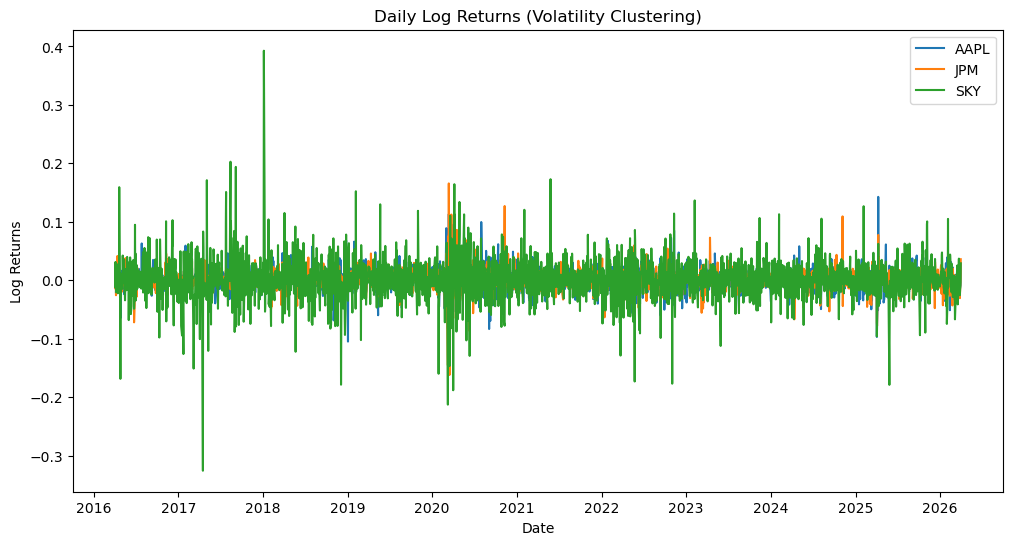

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

for ticker in log_returns.columns:
    plt.plot(log_returns.index, log_returns[ticker], label=ticker)

plt.title("Daily Log Returns (Volatility Clustering)")
plt.xlabel("Date")
plt.ylabel("Log Returns")
plt.legend()
plt.show()

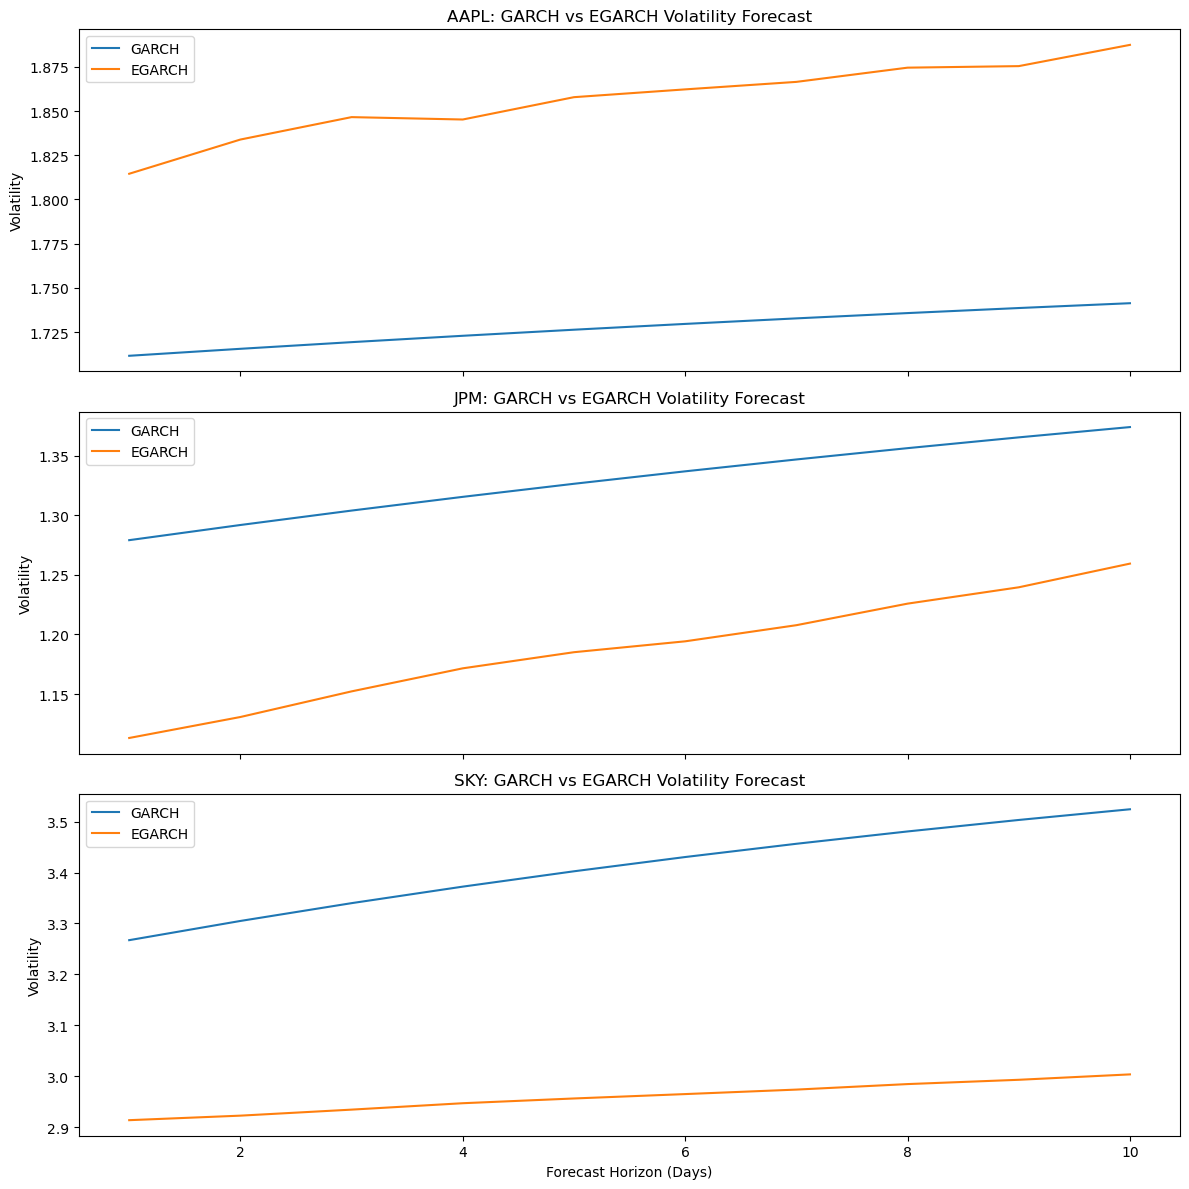

In [45]:
fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)

tickers = ["AAPL", "JPM", "SKY"]
horizon = range(1, 11)  # 👈 FIX

for i, ticker in enumerate(tickers):

    axes[i].plot(
        horizon,
        garch_vol_forecasts[ticker].values,
        label="GARCH"
    )
    
    axes[i].plot(
        horizon,
        egarch_forecasts[ticker].values,
        label="EGARCH"
    )
    
    axes[i].set_title(f"{ticker}: GARCH vs EGARCH Volatility Forecast")
    axes[i].set_ylabel("Volatility")
    axes[i].legend()

plt.xlabel("Forecast Horizon (Days)")
plt.tight_layout()
plt.show()

In [47]:
rolling_vol = {}

for ticker in log_returns_pct.columns:
    rolling_vol[ticker] = log_returns_pct[ticker].rolling(window=30).std()

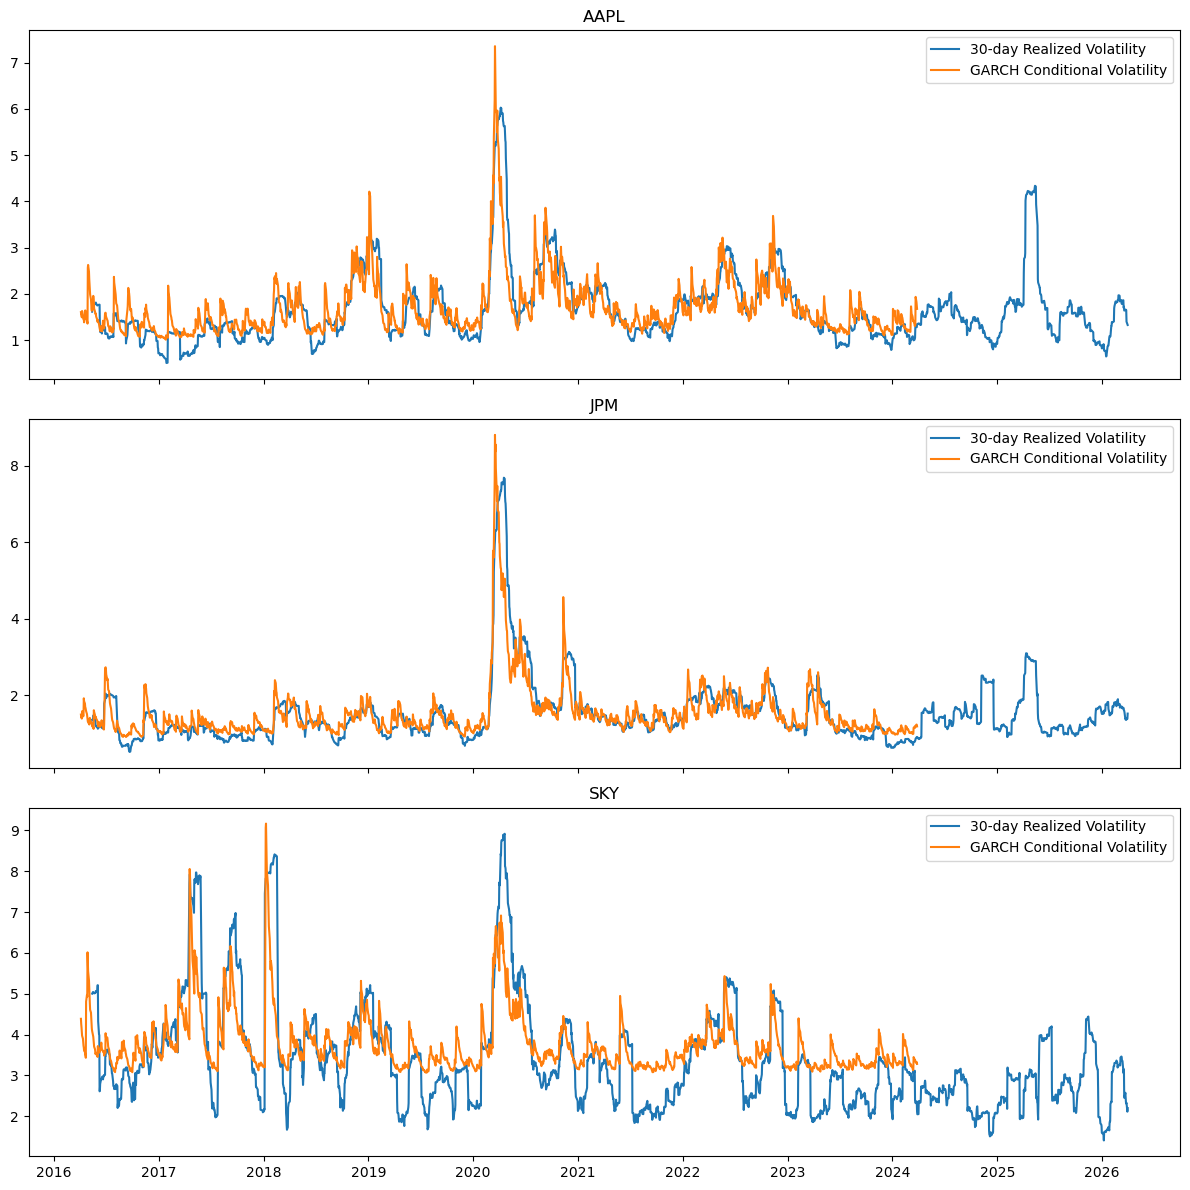

In [49]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)

tickers = ["AAPL", "JPM", "SKY"]

for i, ticker in enumerate(tickers):

    # -------------------------
    # Full realized volatility
    # -------------------------
    rv = rolling_vol[ticker]

    axes[i].plot(
        rv.index,
        rv.values,
        label="30-day Realized Volatility"
    )

    # -------------------------
    # GARCH conditional volatility (FULL SERIES)
    # -------------------------
    axes[i].plot(
        garch_vol[ticker].index,
        garch_vol[ticker].values,
        label="GARCH Conditional Volatility"
    )

    axes[i].set_title(ticker)
    axes[i].legend()

plt.tight_layout()
plt.show()

In [163]:
garch_vol = {}

for ticker in log_returns_pct.columns:
    model = arch_model(train[ticker], vol='Garch', p=1, q=1)
    res = model.fit(disp='off')
    
    garch_vol[ticker] = res.conditional_volatility

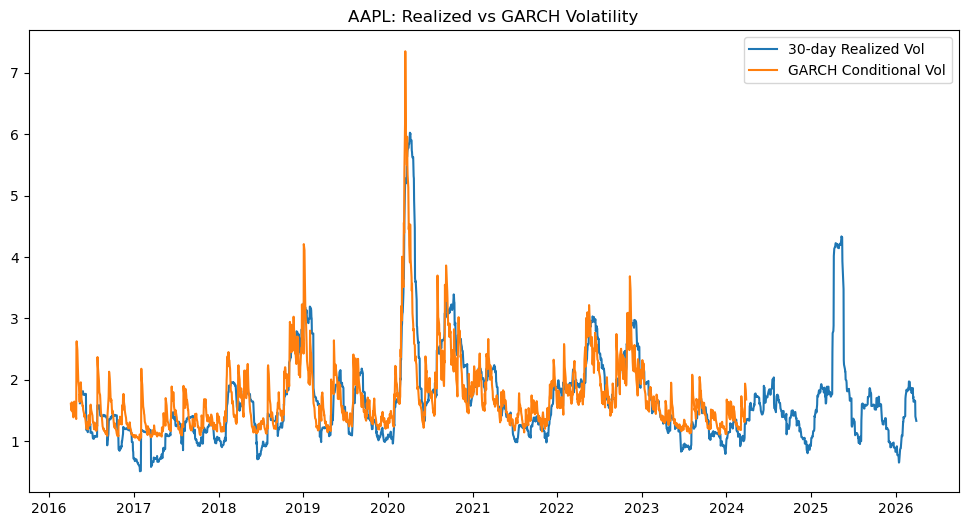

In [165]:
plt.figure(figsize=(12,6))

ticker = "AAPL"

plt.plot(rolling_vol[ticker], label="30-day Realized Vol")
plt.plot(garch_vol[ticker], label="GARCH Conditional Vol")

plt.legend()
plt.title("AAPL: Realized vs GARCH Volatility")
plt.show()

In [167]:
for ticker in ["AAPL", "JPM", "SKY"]:
    rv = rolling_vol[ticker].dropna()
    gv = garch_vol[ticker].dropna()

    print(f"\n{ticker}")
    print(f"Realized Vol -> min: {rv.min():.3f}, max: {rv.max():.3f}, mean: {rv.mean():.3f}")
    print(f"GARCH Vol    -> min: {gv.min():.3f}, max: {gv.max():.3f}, mean: {gv.mean():.3f}")


AAPL
Realized Vol -> min: 0.507, max: 6.025, mean: 1.659
GARCH Vol    -> min: 1.011, max: 7.353, mean: 1.713

JPM
Realized Vol -> min: 0.520, max: 7.692, mean: 1.510
GARCH Vol    -> min: 0.909, max: 8.813, mean: 1.531

SKY
Realized Vol -> min: 1.409, max: 8.915, mean: 3.380
GARCH Vol    -> min: 3.071, max: 9.164, mean: 3.756


In [59]:
import numpy as np

garch_test_forecast = {}

for ticker in results.keys():
    
    res = results[ticker]
    
    forecast = res.forecast(horizon=len(test))
    
    # take last available forecast row correctly
    var = forecast.variance.values[-1]
    
    vol = np.sqrt(var)
    
    garch_test_forecast[ticker] = vol

In [65]:
import numpy as np
import pandas as pd

evaluation = {}

for ticker in results.keys():
    
    # predicted volatility
    pred_vol = garch_test_forecast[ticker]
    
    # actual realized volatility on test set
    actual_vol = log_returns_pct[ticker].loc[test.index].rolling(30).std()
    
    # align both properly (drop NaNs + match length)
    actual_vol = actual_vol.dropna().values
    
    # match lengths
    min_len = min(len(pred_vol), len(actual_vol))
    
    pred_vol = pred_vol[-min_len:]
    actual_vol = actual_vol[-min_len:]
    
    # metrics
    mae = np.mean(np.abs(pred_vol - actual_vol))
    rmse = np.sqrt(np.mean((pred_vol - actual_vol)**2))
    
    evaluation[ticker] = {"MAE": mae, "RMSE": rmse}

evaluation

{'AAPL': {'MAE': 0.4971314000395365, 'RMSE': 0.7489033176738396},
 'JPM': {'MAE': 0.3880633683906405, 'RMSE': 0.5065355254220976},
 'SKY': {'MAE': 1.1521724552412795, 'RMSE': 1.2875357499326412}}

In [67]:
import numpy as np

egarch_test_forecast = {}
egarch_evaluation = {}

# --- Step 1: get EGARCH forecasts ---
for ticker in egarch_results.keys():
    
    res = egarch_results[ticker]
    
    forecast = res.forecast(horizon=len(test), method="simulation")
    
    var = forecast.variance.values[-1]
    vol = np.sqrt(var)
    
    egarch_test_forecast[ticker] = vol

# --- Step 2: evaluate vs realized volatility ---
for ticker in egarch_results.keys():
    
    pred_vol = egarch_test_forecast[ticker]
    
    actual_vol = log_returns_pct[ticker].loc[test.index].rolling(30).std()
    actual_vol = actual_vol.dropna().values
    
    min_len = min(len(pred_vol), len(actual_vol))
    
    pred_vol = pred_vol[-min_len:]
    actual_vol = actual_vol[-min_len:]
    
    mae = np.mean(np.abs(pred_vol - actual_vol))
    rmse = np.sqrt(np.mean((pred_vol - actual_vol)**2))
    
    egarch_evaluation[ticker] = {"MAE": mae, "RMSE": rmse}

egarch_evaluation

{'AAPL': {'MAE': 0.5648774992494038, 'RMSE': 0.7769268970251322},
 'JPM': {'MAE': 0.45915397188157087, 'RMSE': 0.5497258431026315},
 'SKY': {'MAE': 1.7952489321626808, 'RMSE': 1.9472612907856697}}

In [69]:
import numpy as np

benchmark_results = {}

for ticker in log_returns_pct.columns:
    
    # realized volatility (same as before)
    actual_vol = log_returns_pct[ticker].rolling(30).std().dropna()
    
    # simple rolling forecast (benchmark)
    rolling_vol = actual_vol.shift(1).dropna()
    
    # align
    min_len = min(len(rolling_vol), len(actual_vol[1:]))
    
    actual = actual_vol[1:].values[-min_len:]
    pred = rolling_vol.values[-min_len:]
    
    mae = np.mean(np.abs(pred - actual))
    rmse = np.sqrt(np.mean((pred - actual)**2))
    
    benchmark_results[ticker] = {"MAE": mae, "RMSE": rmse}

benchmark_results

{'AAPL': {'MAE': 0.04316042273504181, 'RMSE': 0.09299325483577522},
 'JPM': {'MAE': 0.04045131225208926, 'RMSE': 0.09406047185902602},
 'SKY': {'MAE': 0.09164182941404467, 'RMSE': 0.2418487982492526}}

In [84]:
import numpy as np
from scipy import stats

# -------------------------
# Diebold-Mariano test function
# -------------------------
def dm_test(e1, e2):
    d = (e1**2) - (e2**2)
    
    dm_stat = np.mean(d) / np.sqrt(np.var(d, ddof=1) / len(d))
    
    p_value = 2 * (1 - stats.norm.cdf(abs(dm_stat)))
    
    return dm_stat, p_value


# -------------------------
# Run DM test for each ticker
# -------------------------
dm_results = {}

for ticker in log_returns_pct.columns:
    
    # Actual realized volatility (test period)
    actual = log_returns_pct[ticker].loc[test.index].rolling(30).std().dropna().values
    
    # GARCH predictions (from your forecast step)
    pred_garch = garch_test_forecast[ticker]
    
    # Rolling benchmark (naive forecast)
    rolling_pred = np.roll(actual, 1)
    
    # Align lengths
    min_len = min(len(actual), len(pred_garch), len(rolling_pred))
    
    actual = actual[-min_len:]
    pred_garch = pred_garch[-min_len:]
    rolling_pred = rolling_pred[-min_len:]
    
    # Errors
    e_garch = actual - pred_garch
    e_roll = actual - rolling_pred
    
    # DM test
    dm_stat, p_val = dm_test(e_garch, e_roll)
    
    dm_results[ticker] = {
        "DM stat": dm_stat,
        "p-value": "{:.10e}".format(p_val)
    }


dm_results

{'AAPL': {'DM stat': 9.089262749224186, 'p-value': '0.0000000000e+00'},
 'JPM': {'DM stat': 11.914965753512357, 'p-value': '0.0000000000e+00'},
 'SKY': {'DM stat': 25.462872845306485, 'p-value': '0.0000000000e+00'}}

## COnc

This project evaluated the performance of GARCH(1,1) and EGARCH(1,1) models in forecasting daily volatility for AAPL, JPM, and SKY using 10 years of log return data. Forecast accuracy was assessed using MAE, RMSE, and the Diebold–Mariano test against a 30-day rolling volatility benchmark.

Overall, both GARCH and EGARCH successfully captured volatility dynamics, but their predictive performance varied across assets.

For GARCH:

AAPL MAE: 0.497, RMSE: 0.749
JPM MAE: 0.388, RMSE: 0.507
SKY MAE: 1.152, RMSE: 1.288

For EGARCH:

AAPL MAE: 0.565, RMSE: 0.777
JPM MAE: 0.459, RMSE: 0.550
SKY MAE: 1.795, RMSE: 1.947

In comparison, the rolling volatility benchmark achieved substantially lower errors:

AAPL MAE: 0.043, RMSE: 0.093
JPM MAE: 0.040, RMSE: 0.094
SKY MAE: 0.092, RMSE: 0.242

This performance difference was confirmed statistically using the Diebold–Mariano test. Across all assets, DM statistics were highly significant:

AAPL: 9.09
JPM: 11.91
SKY: 25.46
with p-values effectively equal to zero (p < 1e-10 in all cases), indicating a statistically significant difference in predictive accuracy.

Despite strong model fit characteristics—such as significant leverage effects (γ ≈ -0.113 for AAPL, -0.100 for JPM, -0.032 for SKY) and high volatility persistence (β ≈ 0.95–0.99)—these advantages did not translate into superior short-horizon forecasting performance.

In conclusion, while GARCH and EGARCH provide strong structural modeling of volatility (clustering and asymmetry), the simple rolling volatility model delivers superior out-of-sample forecasting accuracy for all tested assets in this study. This highlights an important practical insight in quantitative finance: model complexity does not necessarily improve predictive performance, especially at short horizons.